In [ ]:
# Latest as of Nov 18 - main script in kirthi_shanbhag@berkeley

# In this file we will explore some models for analysing DrugReview dataset from hugging face.
version V3 - consists of experiement with downsample without statify and using ds_test for predicting

In [ ]:
import re
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
#from sklearn.metrics import accuracy_score, f1_score, precision_score,precision_recall_fscore_support, recall_score
from sklearn.metrics import classification_report,precision_recall_fscore_support, accuracy_score,precision_score, recall_score, f1_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from datasets import load_dataset,Dataset,concatenate_datasets
from sklearn.utils.class_weight import compute_class_weight
from collections import Counter
from torch.utils.data import DataLoader, WeightedRandomSampler

from transformers import (
    T5Tokenizer,
    T5ForConditionalGeneration,
    Trainer,
    TrainingArguments,
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    AutoModelForSequenceClassification,
    EarlyStoppingCallback,
    DataCollatorWithPadding
)

#from datasets import Dataset
import torch

from torch.utils.data import DataLoader, WeightedRandomSampler, TensorDataset

In [ ]:
import os
os.environ["WANDB_DISABLED"] = "true"


In [ ]:
dryRun = False

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive/')

colab_dir = "/content/gdrive/MyDrive/Colab Notebooks/"
base_dir = colab_dir + "d266/FinalProject/"

Mounted at /content/gdrive/


# Load Dataset

In [ ]:
# Load and preprocess dataset

ds = load_dataset("Mouwiya/drug-reviews")   # Hugging Face dataset
df = ds["train"].to_pandas().dropna(subset=["drugName", "condition", "review", "rating"])

# Collapse ratings into 5 buckets
def collapse_rating(r):
    if r in [1, 2]:
        return 0
    elif r in [3, 4]:
        return 1
    elif r in [5, 6]:
        return 2
    elif r in [7, 8]:
        return 3
    else:
        return 4

df["rating_bucket"] = df["rating"].apply(collapse_rating)


# Basic Cleaning

# Dictionary for reference
label_map = {
    "0": "1-2 stars",
    "1": "3-4 stars",
    "2": "5-6 stars",
    "3": "7-8 stars",
    "4": "9-10 stars"
}
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"<.*?>", " ", text)         # remove HTML tags
    text = re.sub(r"['\"`]", "", text)         # remove quotes
    text = re.sub(r"[^a-z0-9.,!?;:() ]", " ", text)  # remove special characters
    text = re.sub(r"\s+", " ", text).strip()   # normalize whitespace
    return text

df["drugName"] = df["drugName"].apply(clean_text)
df["condition"] = df["condition"].apply(clean_text)
df["review"] = df["review"].apply(clean_text)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/9.57M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/16.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/27703 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/46108 [00:00<?, ? examples/s]

In [ ]:

print("EDA SUMMARY: ")
print("*"*35)
print("Dataset shape:", df.shape)
print("\nMissing values per column:\n", df.isna().sum())

print("\nRating bucket distribution:")
print(df["rating_bucket"].value_counts(normalize=True).round(3))

# Average review length
df["review_length"] = df["review"].apply(lambda x: len(x.split()))
print("\nAverage review length:", df["review_length"].mean())
print("Shortest review length:", df["review_length"].min())
print("Longest review length:", df["review_length"].max())

# Example cleaned text
print("\nSample cleaned review:\n", df["review"].iloc[0][:500], "...")

EDA SUMMARY: 
***********************************
Dataset shape: (27703, 9)

Missing values per column:
 patient_id       0
drugName         0
condition        0
review           0
rating           0
date             0
usefulCount      0
review_length    0
rating_bucket    0
dtype: int64

Rating bucket distribution:
rating_bucket
4    0.479
3    0.183
0    0.170
2    0.094
1    0.074
Name: proportion, dtype: float64

Average review length: 95.24387250478287
Shortest review length: 28
Longest review length: 1181

Sample cleaned review:
 sober a year 8 25 11. god, aa and campral have worked. no cravings i couldnt handle. together all have helped me have a new lease on life. feel better, work has improved. highly recommend this medicine if you want to quit drinking. ...


Class distribution:
 rating_bucket
0     4700
1     2043
2     2616
3     5071
4    13273
Name: count, dtype: int64


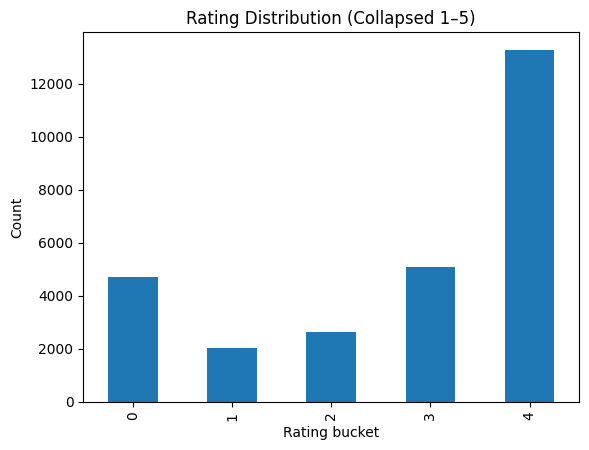

In [ ]:
# Check distribution (imbalance)
rating_counts = df["rating_bucket"].value_counts().sort_index()
print("Class distribution:\n", rating_counts)

# visualize the distribution
rating_counts.plot(kind="bar", title="Rating Distribution (Collapsed 1–5)")
plt.xlabel("Rating bucket")
plt.ylabel("Count")
plt.show()

# Define the feature/text and label

In [ ]:
#df["text"] = df["drugName"].astype(str) + " | " + df["condition"].astype(str) + " | " + df["review"].astype(str)
#y = df["rating_bucket"].values.astype(str)

In [ ]:
#df["text"] = df["drugName"].astype(str) + " | " + df["condition"].astype(str) + " | " + df["review"].astype(str)
df["text"] =  df["review"].astype(str)
y = df["rating_bucket"].values

In [ ]:
print("Input text dimensions :", df.shape)
print("Label dimnensions : ",len(y))

Input text dimensions : (27703, 10)
Label dimnensions :  27703


# Baseline Model Section

In [ ]:
# Stratified Split

train_df, val_df, y_train, y_val = train_test_split(
    df["text"], y, test_size=0.2, random_state=42, stratify=y
)


### TF-IDF Vectorization

In [ ]:
tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1, 2), stop_words="english")
X_train = tfidf.fit_transform(train_df)
X_val = tfidf.transform(val_df)

In [ ]:
# Weighted Random Sampler (for balancing)

class_counts = np.bincount(y_train)
class_weights = 1. / class_counts
sample_weights = class_weights[y_train]

sampler = WeightedRandomSampler(
    weights=torch.DoubleTensor(sample_weights),
    num_samples=len(sample_weights),
    replacement=True
)

In [ ]:
# For completeness (if using in PyTorch pipelines later)
train_tensor = torch.tensor(X_train.toarray(), dtype=torch.float32)
val_tensor = torch.tensor(X_val.toarray(), dtype=torch.float32)
train_labels_tensor = torch.tensor(y_train, dtype=torch.long)
val_labels_tensor = torch.tensor(y_val, dtype=torch.long)

train_dataset = TensorDataset(train_tensor, train_labels_tensor)
val_dataset = TensorDataset(val_tensor, val_labels_tensor)

train_loader = DataLoader(train_dataset, sampler=sampler, batch_size=64)

print(f"Train samples: {len(train_dataset)}, Validation samples: {len(val_dataset)}")

Train samples: 22162, Validation samples: 5541


In [ ]:
if not dryRun:
  # Logistic Regression
  model = LogisticRegression(max_iter=300)
  model.fit(X_train, y_train)
  y_pred = model.predict(X_val)
  print("Accuracy:", accuracy_score(y_val, y_pred))
  print("\nClassification Report:\n", classification_report(y_val, y_pred, target_names=[label_map[str(i)] for i in range(5)]))
  #Accuracy: 0.5908680743548096


Accuracy: 0.5946580039704025

Classification Report:
               precision    recall  f1-score   support

   1-2 stars       0.58      0.63      0.60       940
   3-4 stars       0.36      0.04      0.07       409
   5-6 stars       0.42      0.10      0.16       523
   7-8 stars       0.38      0.22      0.28      1014
  9-10 stars       0.64      0.91      0.75      2655

    accuracy                           0.59      5541
   macro avg       0.48      0.38      0.37      5541
weighted avg       0.54      0.59      0.53      5541



In [ ]:
# Linear SVM
if not dryRun:
  model = LinearSVC(class_weight="balanced")

  model.fit(X_train, y_train)
  y_pred = model.predict(X_val)
  print("Accuracy:", accuracy_score(y_val, y_pred))
  print("\nClassification Report:\n", classification_report(y_val, y_pred, target_names=[label_map[str(i)] for i in range(5)]))
  #Accuracy: 0.5663237682728749

Accuracy: 0.567767550983577

Classification Report:
               precision    recall  f1-score   support

   1-2 stars       0.57      0.62      0.59       940
   3-4 stars       0.25      0.23      0.24       409
   5-6 stars       0.27      0.29      0.28       523
   7-8 stars       0.37      0.35      0.36      1014
  9-10 stars       0.75      0.74      0.75      2655

    accuracy                           0.57      5541
   macro avg       0.44      0.45      0.44      5541
weighted avg       0.57      0.57      0.57      5541



In [ ]:
# Option 2: Random Forest
if not dryRun:
  model = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42)
  # -----------------------------
  # Train & Evaluate
  # -----------------------------
  model.fit(X_train, y_train)
  y_pred = model.predict(X_val)
  print("Accuracy:", accuracy_score(y_val, y_pred))
  print("\nClassification Report:\n", classification_report(y_val, y_pred, target_names=[label_map[str(i)] for i in range(5)]))
  #Accuracy: 0.5693918065331167


Accuracy: 0.5681284966612525

Classification Report:
               precision    recall  f1-score   support

   1-2 stars       0.67      0.37      0.47       940
   3-4 stars       1.00      0.09      0.16       409
   5-6 stars       1.00      0.10      0.19       523
   7-8 stars       0.96      0.09      0.16      1014
  9-10 stars       0.54      0.99      0.70      2655

    accuracy                           0.57      5541
   macro avg       0.83      0.33      0.34      5541
weighted avg       0.72      0.57      0.47      5541



# Sample Strategy

In [ ]:
def upsample_dataset(dataset, label_col="labels", seed=42):
    random.seed(seed)
    labels = dataset[label_col]
    counts = Counter(labels)
    max_count = max(counts.values())

    upsampled_subsets = []
    for label in counts:
        subset = dataset.filter(lambda x: x[label_col] == label)
        # Repeat samples until we reach or exceed max_count
        repeat_factor = max_count // len(subset) + 1
        repeated = concatenate_datasets([subset] * repeat_factor)
        # Trim to exact size
        repeated = repeated.select(range(max_count))
        upsampled_subsets.append(repeated)

    # Combine all classes into one dataset
    balanced_dataset = concatenate_datasets(upsampled_subsets).shuffle(seed=seed)

    print("After upsampling:", Counter(balanced_dataset[label_col]))
    return balanced_dataset

In [ ]:
def downsample_dataset(dataset, label_col="labels", seed=42):
    """
    Downsample a Hugging Face Dataset to balance all classes
    by reducing majority class samples.
    """
    counts = Counter(dataset[label_col])
    min_count = min(counts.values())

    print(f"Original class distribution: {counts}")
    print(f"Target samples per class: {min_count}\n")

    downsampled_subsets = []
    for label in counts:
        subset = dataset.filter(lambda x: x[label_col] == label)
        subset = subset.shuffle(seed=seed).select(range(min_count))
        downsampled_subsets.append(subset)

    # Merge all balanced subsets and shuffle
    balanced_dataset = concatenate_datasets(downsampled_subsets).shuffle(seed=seed)

    print("After downsampling:", Counter(balanced_dataset[label_col]))
    return balanced_dataset

#balanced_train_ds = downsample_dataset(train_ds, label_col='labels')
#print("After downsampling:")
#print(Counter(balanced_train_ds['labels']))

In [ ]:
# This may not work. TBD
def weighted_sample_dataset(dataset, label_col="labels", seed=42):
  label_counts = Counter(dataset[label_col])
  num_samples = len(label_counts.values())
  class_weights = {cls: num_samples / (len(label_counts) * count) for cls, count in label_counts.items()}
  weights = [class_weights[label] for label in dataset[label_col]]
  sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)
  return sampler


# Fine Tuning Section

# Training test splits

In [ ]:
stratify = "stratify" # Use stratify = None if you want to disable it and then use upsampling instead.


if not stratify:
  # Choose from ["stratify", "downsample", "upsample", "weightedsample"] for training data, This will manage the imbalancein dataset
  sample_strategy = "upsample"
else:
  sample_strategy = None

if sample_strategy == "stratify":
  train_df, val_df, y_train, y_val = train_test_split(
      df, y, test_size=0.2, random_state=42, stratify=y
  )
else:
  train_df, val_df, y_train, y_val = train_test_split(
      df, y, test_size=0.2, random_state=42,
  )
  #val_df,y_val,test_df,y_test = train_test_split(tmp_df,tmp_val, test_size=0.5, stratify=tmp_val, random_state=42)

In [ ]:
print("Train split shape :",train_df.shape)
print("Train Label length : ",len(y_train))
print("Val split shape :",val_df.shape)
print("Val Label length : ",len(y_val))
#print("Test split shape :",test_df.shape)
#print("Test Label length : ",len(y_test))

Train split shape : (22162, 10)
Train Label length :  22162
Val split shape : (5541, 10)
Val Label length :  5541


# Convert to Hugging Face Dataset

In [ ]:

#train_ds = Dataset.from_pandas(train_df[["text", "label_text"]])
#val_ds = Dataset.from_pandas(val_df[["text", "label_text"]])
#train_df["label_text"] = train_df["rating_bucket"].astype(str)
#val_df["label_text"] = val_df["rating_bucket"].astype(str)

train_ds = Dataset.from_pandas(train_df[["text", "rating_bucket"]].rename(columns={"rating_bucket": "labels"}))
val_ds = Dataset.from_pandas(val_df[["text", "rating_bucket"]].rename(columns={"rating_bucket": "labels"}))

# Define model name and Tokenizer

In [ ]:
if sample_strategy == "downsample":
  print("Applying downsample to the dataset")
  balanced_train_ds = downsample_dataset(train_ds, label_col='labels')
elif sample_strategy == "upsample":
  print("Applying upsample to the dataset")
  balanced_train_ds = upsample_dataset(train_ds, label_col='labels')
elif sample_strategy == "weightedsample":
  print("Applying weighted to the dataset")
  #balanced_train_ds = weighted_sample_dataset(train_ds, label_col='labels')
  print("This code does not work. ")
  import sys
  sys.exit()
#print("After upsampling:")
#print(Counter(balanced_train_ds['labels']))

# Prepare Test data

In [ ]:
df_test = ds["test"].to_pandas().dropna().reset_index(drop=True)
# Keep only necessary columns
df_test = df_test[["drugName", "condition", "review", "rating"]]

df_test["rating_bucket"] = df_test["rating"].apply(collapse_rating).astype(int)

df_test["drugName"] = df_test["drugName"].apply(clean_text)
df_test["condition"] = df_test["condition"].apply(clean_text)
df_test["review"] = df_test["review"].apply(clean_text)
# create combined text field used as model input
#df_test["text"] = df_test["drugName"].astype(str) + " | " + df_test["condition"].astype(str) + " | " + df_test["review"].astype(str)
df_test["text"] =  df["review"].astype(str)
df_test  = Dataset.from_pandas(df_test[["text", "rating_bucket"]].rename(columns={"rating_bucket": "labels"}))
df_test

Dataset({
    features: ['text', 'labels'],
    num_rows: 46108
})

# Zero-shot prediction
Lets evaluate the pre-trained T5 model as zero-shot classification. Validate if the base model performs better than fine-tuning!!

In [ ]:
from transformers import pipeline
t5_model_name = "t5-base"
classifier = pipeline("zero-shot-classification",model=t5_model_name,)


sample_text = df_test["text"]
result = classifier(
    sample_text,
    candidate_labels=["1-2 stars", "3-4 stars", "5-6 stars", "7-8 stars", "9-10 stars"]
)
print("Predicted Probability",result['scores'])
result['labels'][0]
"""
# Zero shot accuracy
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import torch
from datasets import Dataset
from sklearn.metrics import accuracy_score

# ---------------------------
# 1. Load model & tokenizer
# ---------------------------
model_name = "t5-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name).to("cuda")

# ---------------------------
# 2. Example test dataset
# ---------------------------
# Your df_test must contain columns: text, labels
# labels must be strings ("0","1","2","3","4") or ints

df_test = [
    {"text": "The medicine worked great and I feel better", "labels": "4"},
    {"text": "This made me very sick, terrible experience", "labels": "0"},
]

test_ds = Dataset.from_list(df_test)

# ---------------------------
# 3. Zeroshot prediction function
# ---------------------------
def t5_zeroshot_predict(text):
    prompt = f"classify: {text}"

    inputs = tokenizer(prompt, return_tensors="pt", truncation=True).to("cuda")

    outputs = model.generate(
        **inputs,
        max_length=4,        # label is short
        num_beams=4,
    )

    pred = tokenizer.decode(outputs[0], skip_special_tokens=True).strip()

    # clean output (remove any extra text)
    pred = pred.replace(" ", "")
    return pred

# ---------------------------
# 4. Generate predictions for full test set
# ---------------------------
y_true = []
y_pred = []

for row in test_ds:
    true_label = str(row["labels"])
    pred_label = t5_zeroshot_predict(row["text"])

    # optional: restrict to valid label set
    if pred_label not in ["0", "1", "2", "3", "4"]:
        pred_label = "unknown"

    y_true.append(true_label)
    y_pred.append(pred_label)

# ---------------------------
# 5. Compute accuracy
# ---------------------------
acc = accuracy_score(y_true, y_pred)
print("Zero-shot T5-base Accuracy:", acc)

"""


config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/892M [00:00<?, ?B/s]

Some weights of T5ForSequenceClassification were not initialized from the model checkpoint at t5-base and are newly initialized: ['classification_head.dense.bias', 'classification_head.dense.weight', 'classification_head.out_proj.bias', 'classification_head.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

Device set to use cuda:0
Failed to determine 'entailment' label id from the label2id mapping in the model config. Setting to -1. Define a descriptive label2id mapping in the model config to ensure correct outputs.
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


Predicted Probability [0.2020835131406784, 0.20088835060596466, 0.2004697173833847, 0.19907523691654205, 0.19748318195343018]


'\n# Zero shot accuracy\nfrom transformers import AutoTokenizer, AutoModelForSeq2SeqLM\nimport torch\nfrom datasets import Dataset\nfrom sklearn.metrics import accuracy_score\n\n# ---------------------------\n# 1. Load model & tokenizer\n# ---------------------------\nmodel_name = "t5-base"\ntokenizer = AutoTokenizer.from_pretrained(model_name)\nmodel = AutoModelForSeq2SeqLM.from_pretrained(model_name).to("cuda")\n\n# ---------------------------\n# 2. Example test dataset\n# ---------------------------\n# Your df_test must contain columns: text, labels\n# labels must be strings ("0","1","2","3","4") or ints\n\ndf_test = [\n    {"text": "The medicine worked great and I feel better", "labels": "4"},\n    {"text": "This made me very sick, terrible experience", "labels": "0"},\n]\n\ntest_ds = Dataset.from_list(df_test)\n\n# ---------------------------\n# 3. Zeroshot prediction function\n# ---------------------------\ndef t5_zeroshot_predict(text):\n    prompt = f"classify: {text}"\n\n    i

# Fine Tuning the T5 model with DrugReview Dataset

## Token config

In [ ]:
model_name = "t5-base" # Model name
if os.path.exists(base_dir+"t5_basetoken"):
  print("Loaded base model from local folder:",base_dir+"t5_basetoken")
  tokenizer = AutoTokenizer.from_pretrained(base_dir+"t5_basetoken")
else:
  print("Loading base model from Hugging Face")
  tokenizer = AutoTokenizer.from_pretrained(model_name)
  tokenizer.save_pretrained(base_dir+"t5_basetoken")

Loading base model from Hugging Face


In [ ]:
if not sample_strategy == None:
  print(f"Applying {sample_strategy} to the dataset")

In [ ]:
# chanegs for imoproving max_length=2 - > 512
def preprocess_function(examples):
    inputs = ["Classify this review into rating 0–4: " + text for text in examples["text"]]
    # max_length =256
    model_inputs = tokenizer(inputs, max_length=128, truncation=True, padding="max_length")

    # Convert labels to string tokens
    # padding="max_length"
    with tokenizer.as_target_tokenizer():
        labels = tokenizer([str(label) for label in examples["labels"]],
                           max_length=2, truncation=True, padding=False)

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

if not sample_strategy == None:
  print(f"Applying {sample_strategy} to the dataset")
  tokenized_train = balanced_train_ds.map(preprocess_function, batched=True)
else:
  tokenized_train = train_ds.map(preprocess_function, batched=True)
tokenized_val = val_ds.map(preprocess_function, batched=True)

#===============================================================
# Use this line when you want to experiment with smaller data set
#===============================================================
if dryRun:
  print("Applying dryRunConfig")
  tokenized_train = tokenized_train.select(range(100))
  tokenized_val = tokenized_val.select(range(20))
  num_train_epochs = 1
  train_batch_size = 4
  val_batch_size = 4
else:
  num_train_epochs = 5
  train_batch_size = 8
  val_batch_size = 16


Map:   0%|          | 0/22162 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:4034: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your labels by using the argument `text_target` of the regular `__call__` method (either in the same call as your input texts if you use the same keyword arguments, or in a separate call.
  warnings.warn(


Map:   0%|          | 0/5541 [00:00<?, ? examples/s]

# Load tensorboard dashboard to analyse training

In [ ]:
#!rm -rf ./runs #If you see errors like “TensorBoard already running,” clear it with:

#%load_ext tensorboard
#%tensorboard --logdir ./logs

In [ ]:
custom_cache_path = base_dir+"t5_basemodel_cache"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if os.path.exists(custom_cache_path):
  print("Loading pre-trained from Cache!")
  model = AutoModelForSeq2SeqLM.from_pretrained(custom_cache_path).to(device)
else:
  print("Loading pre-trained from Huging Face")
  model = AutoModelForSeq2SeqLM.from_pretrained(model_name,ignore_mismatched_sizes=True,cache_dir=custom_cache_path).to(device)





Loading pre-trained from Huging Face


config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/892M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

# Zero-Shot

In [ ]:
def t5_zeroshot_predict(text):
    #prompt = f"Classify this review into rating 0–4: {text}"
    #prompt = (
    #    "question: What rating (0,1,2,3,4) best fits this review?\n"
    #    f"review: {text}\n"
    #    "answer:"
    #)
    prompt = (
        "Task: Classify the drug review into a rating from 0 to 4.\n"
        "Ratings: 0=Very Bad, 1=Bad, 2=Neutral, 3=Good, 4=Excellent.\n"
        f"Review: {text}\n"
        "Answer with ONLY a single digit (0–4):"
    )
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True,padding=False)
    inputs.pop("token_type_ids", None)
    inputs = inputs.to(device)




    model.to(device)
    outputs = model.generate(
        **inputs,
        max_length=2,        # label is short
        num_beams=4,
    )
    print("output",outputs)

    pred = tokenizer.decode(outputs[0], skip_special_tokens=True).strip()
    #print("Pred",)
    # clean output (remove any extra text)
    pred = pred.replace(" ", "")
    return pred

# ---------------------------
# 4. Generate predictions for full test set
# ---------------------------
y_true = []
y_pred = []
from transformers import pipeline
t5_model_name = "t5-base"

df_test = df_test.select(range(15))
tokenized_test = df_test.map(preprocess_function, batched=True)

tokenized_test.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
tokenized_test = tokenized_test.select(range(1))

for row in tokenized_test:
    true_label = str(row["labels"])
    #print("row",row)
    pred_label = t5_zeroshot_predict(row["input_ids"])
    print("what is predlabel",pred_label)
    # optional: restrict to valid label set
    if pred_label not in ["0", "1", "2", "3", "4"]:
        pred_label = "unknown"

    y_true.append(true_label)
    y_pred.append(pred_label)

# ---------------------------
# Compute Metrics
# ---------------------------
#acc = accuracy_score(y_true, y_pred)
#print("Zero-shot T5-base Accuracy:", acc)
# Convert labels to strings (SAFEST)
y_true = [str(y) for y in y_true]
y_pred = [str(y) for y in y_pred]
print(y_pred)
# ---------------------------
# Metrics
# ---------------------------
acc = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average="weighted", zero_division=0)
recall = recall_score(y_true, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

print("Accuracy:", acc)
print("Precision (weighted):", precision)
print("Recall (weighted):", recall)
print("F1 Score (weighted):", f1)

# Optional detailed report
print("\nZero-shot T5-base Classification Report:")
print(classification_report(y_true, y_pred, zero_division=0))

Map:   0%|          | 0/15 [00:00<?, ? examples/s]

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


output tensor([[    0, 10747]], device='cuda:0')
what is predlabel Fal
['unknown']
Accuracy: 0.0
Precision (weighted): 0.0
Recall (weighted): 0.0
F1 Score (weighted): 0.0

Zero-shot T5-base Classification Report:
                    precision    recall  f1-score   support

tensor([314,   1])       0.00      0.00      0.00       1.0
           unknown       0.00      0.00      0.00       0.0

          accuracy                           0.00       1.0
         macro avg       0.00      0.00      0.00       1.0
      weighted avg       0.00      0.00      0.00       1.0



# Define metrics

In [ ]:

def compute_metrics(eval_pred):
    preds, labels = eval_pred
    decoded_preds = tokenizer.batch_decode(preds, skip_special_tokens=True)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    # Strip spaces, map to ints if possible
    decoded_preds = [p.strip() for p in decoded_preds]
    decoded_labels = [l.strip() for l in decoded_labels]

    # Filter invalid preds
    valid = [p for p in decoded_preds if p.isdigit()]
    return {
        "accuracy": accuracy_score(decoded_labels, decoded_preds),
        "precision": precision_score(decoded_labels, decoded_preds, average="macro", zero_division=0),
        "recall": recall_score(decoded_labels, decoded_preds, average="macro", zero_division=0),
        "f1": f1_score(decoded_labels, decoded_preds, average="macro", zero_division=0),
        "macro_f1": f1_score(decoded_labels, decoded_preds, average="macro"),
        "weighted_f1": f1_score(decoded_labels, decoded_preds, average="weighted"),
    }



# Training Starts

In [ ]:
model.config.return_dict = True

training_args = Seq2SeqTrainingArguments(
    output_dir=base_dir+"t5_classification",
    seed=42,
    per_device_train_batch_size=train_batch_size,
    per_device_eval_batch_size=val_batch_size,
    num_train_epochs=num_train_epochs,
    learning_rate=5e-5,#3e-4,5e-5,1e-4
    eval_strategy="epoch",
    save_strategy="epoch",
    report_to=None,
    load_best_model_at_end=True,
    metric_for_best_model="weighted_f1",
    greater_is_better=True,

    #early_stopping_patience=3,

    # This was added earlier. Accuracy = 0.60
    gradient_accumulation_steps=2,
    weight_decay=0.01,
    warmup_ratio=0.1,
    lr_scheduler_type="cosine",
    logging_dir="./logs",
    logging_steps=10,
    predict_with_generate=True,
    push_to_hub=False,

)
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)
print("Training Argument : epoch ",num_train_epochs)
trainer.train()

Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
/tmp/ipython-input-1592431472.py:28: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(


Training Argument : epoch  5


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Macro F1,Weighted F1
1,0.566900,0.457118,0.635264,0.511821,0.443141,0.428390,0.428390,0.602151
2,0.450100,0.441636,0.657823,0.519700,0.502133,0.505978,0.505978,0.643211
3,0.345600,0.475896,0.650244,0.518001,0.512694,0.513675,0.513675,0.643524
4,0.224700,0.531801,0.650063,0.523878,0.515697,0.519334,0.519334,0.644774
5,0.250400,0.569304,0.648800,0.524882,0.518441,0.521060,0.521060,0.646539


There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight', 'lm_head.weight'].


TrainOutput(global_step=6930, training_loss=0.4413483130123364, metrics={'train_runtime': 4312.6973, 'train_samples_per_second': 25.694, 'train_steps_per_second': 1.607, 'total_flos': 1.68696559632384e+16, 'train_loss': 0.4413483130123364, 'epoch': 5.0})

# Save the model and tokens

In [ ]:
base_dir = colab_dir + "d266/FinalProject/"

base_dir+"t5base_finetuned_drugreviews"

'/content/gdrive/MyDrive/Colab Notebooks/d266/FinalProject/t5base_finetuned_drugreviews'

In [ ]:

# -------------------------
# 10) Save model and tokenizer
# -------------------------
base_dir = colab_dir + "d266/FinalProject/"

trainer.save_model(base_dir+"t5base_finetuned_drugreviews")
tokenizer.save_pretrained(base_dir+"t5base_finetuned_drugreviews")

print(f"Model, tokenizer saved to {base_dir}t5base_finetuned_drugreviews")

Model, tokenizer saved to /content/gdrive/MyDrive/Colab Notebooks/d266/FinalProject/t5base_finetuned_drugreviews


# Evaluate

In [ ]:
# comment train
metrics = trainer.evaluate()
print("\n=== Evaluation Summary ===")
print(metrics)


=== Evaluation Summary ===
{'eval_loss': 0.569304347038269, 'eval_accuracy': 0.6487998556217289, 'eval_precision': 0.5248822767520263, 'eval_recall': 0.5184405799945231, 'eval_f1': 0.5210604951187054, 'eval_macro_f1': 0.5210604951187054, 'eval_weighted_f1': 0.6465388852251264, 'eval_runtime': 111.7196, 'eval_samples_per_second': 49.597, 'eval_steps_per_second': 3.106, 'epoch': 5.0}


# Inference/Prediction

# Tokenize the test data

In [ ]:
#tokenized_test  = df_test.map(preprocess_fn, batched=True, remove_columns=["text"])
#preprocess_function
df_test = df_test.select(range(15))
tokenized_test = df_test.map(preprocess_function, batched=True)

tokenized_test.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
tokenized_test = tokenized_test.select(range(15))
print("Tokenised test shape : ",tokenized_test.shape)

Map:   0%|          | 0/15 [00:00<?, ? examples/s]

Tokenised test shape :  (15, 4)


/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:4034: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your labels by using the argument `text_target` of the regular `__call__` method (either in the same call as your input texts if you use the same keyword arguments, or in a separate call.
  warnings.warn(


In [ ]:

print("Test eval:")
preds_output = trainer.predict(tokenized_test)
print(preds_output.metrics)
# -------------------------
# Evaluate on test set
# -------------------------
print("Validation eval:")
print(trainer.evaluate(tokenized_val))

Test eval:


{'test_loss': 2.5924184322357178, 'test_accuracy': 0.4, 'test_precision': 0.3888888888888889, 'test_recall': 0.3, 'test_f1': 0.32, 'test_macro_f1': 0.32, 'test_weighted_f1': 0.38222222222222224, 'test_runtime': 0.3751, 'test_samples_per_second': 39.987, 'test_steps_per_second': 2.666}
Validation eval:


{'eval_loss': 0.569304347038269, 'eval_accuracy': 0.6487998556217289, 'eval_precision': 0.5248822767520263, 'eval_recall': 0.5184405799945231, 'eval_f1': 0.5210604951187054, 'eval_macro_f1': 0.5210604951187054, 'eval_weighted_f1': 0.6465388852251264, 'eval_runtime': 107.527, 'eval_samples_per_second': 51.531, 'eval_steps_per_second': 3.227, 'epoch': 5.0}


In [ ]:
preds_output[0]

array([[  0, 314,   1,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0],
       [  0, 209,   1,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0],
       [  0, 220,   1,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0],
       [  0, 314,   1,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0],
       [  0, 314,   1,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0],
       [  0, 204,   1,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0],
       [  0, 209,   1,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0],
       [  0, 314,   1,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0],
       [  0,   3,   1,   0,   0,   0,   0,   0,   0,   0,   0,  

In [ ]:
label_values = []
decoded_labels = tokenizer.batch_decode(
    preds_output.label_ids, skip_special_tokens=True
)
print(decoded_labels,len(decoded_labels))

#decoded_labels = [int(l.strip()) for l in decoded_labels]
for l in decoded_labels:
  if l:
    try:
      label_values.append(int(l.strip()))
    except:
      p= 100
  else:
    label_values.append(-100)
print(label_values)
len(label_values)

['4', '3', '4', '4', '1', '2', '4', '3', '', '', '2', '', '4', '4', '1'] 15
[4, 3, 4, 4, 1, 2, 4, 3, -100, -100, 2, -100, 4, 4, 1]


15

In [ ]:
preds_values = []
decoded_preds = tokenizer.batch_decode(
    preds_output.predictions, skip_special_tokens=True
)
#decoded_preds = [int(p.strip()) for p in decoded_preds]
print("!",decoded_preds,len(decoded_preds))
for p in decoded_preds:
  if p:
    try:
        p= int(float(p))   # handles "0", "0.0", "1.0", etc.
    except:
        p= -100

    preds_values.append(p)
print(preds_values)
len(preds_values)


! ['4', '1', '3', '4', '4', '2', '1', '4', '', '4', '', '4', '4', '4', '4'] 15
[4, 1, 3, 4, 4, 2, 1, 4, 4, 4, 4, 4, 4]


13

In [ ]:
for i,pl in enumerate(preds_values):
  print(pl,"->",label_values[i])

4 -> 4
1 -> 3
3 -> 4
4 -> 4
4 -> 1
2 -> 2
1 -> 4
4 -> 3
4 -> -100
4 -> -100
4 -> 2
4 -> -100
4 -> 4


In [ ]:

# Create a comparison DataFrame
comparison_df = pd.DataFrame({
    "True Label": decoded_labels,
    "Predicted Label": decoded_preds,
    "Text": tokenized_test["input_ids"]  # Replace 'text' with your actual field name
})

# View some mismatches
comparison_df[comparison_df["True Label"] != comparison_df["Predicted Label"]]

,True Label,Predicted Label,Text
1,3,1,"[tensor(4501), tensor(4921), tensor(48), tenso..."
2,4,3,"[tensor(4501), tensor(4921), tensor(48), tenso..."
4,1,4,"[tensor(4501), tensor(4921), tensor(48), tenso..."
6,4,1,"[tensor(4501), tensor(4921), tensor(48), tenso..."
7,3,4,"[tensor(4501), tensor(4921), tensor(48), tenso..."
9,,4,"[tensor(4501), tensor(4921), tensor(48), tenso..."
10,2,,"[tensor(4501), tensor(4921), tensor(48), tenso..."
11,,4,"[tensor(4501), tensor(4921), tensor(48), tenso..."
14,1,4,"[tensor(4501), tensor(4921), tensor(48), tenso..."


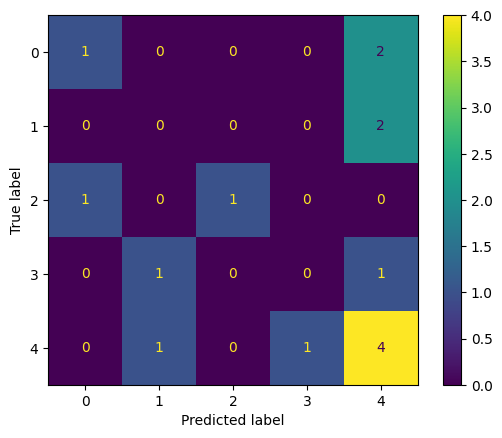

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(decoded_labels, decoded_preds)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.show()
